In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

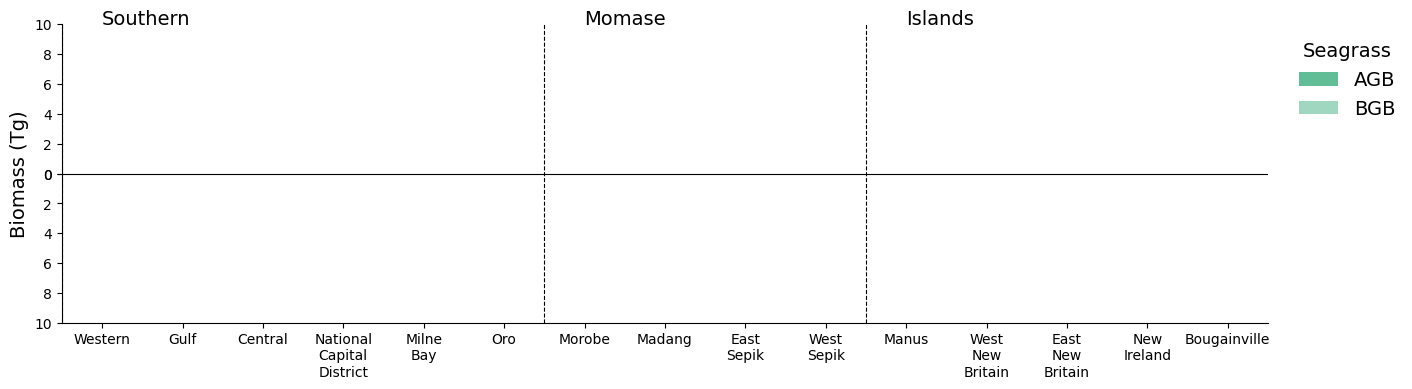

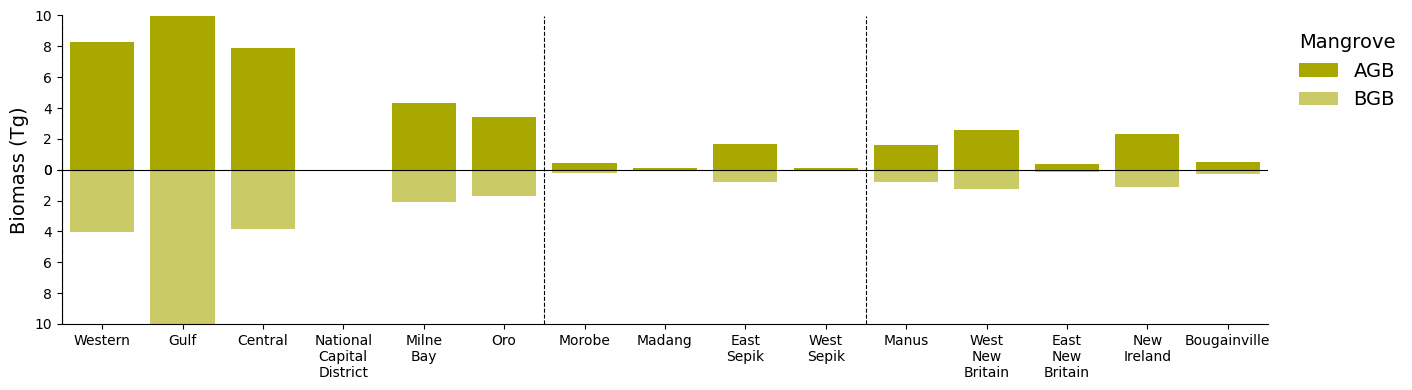

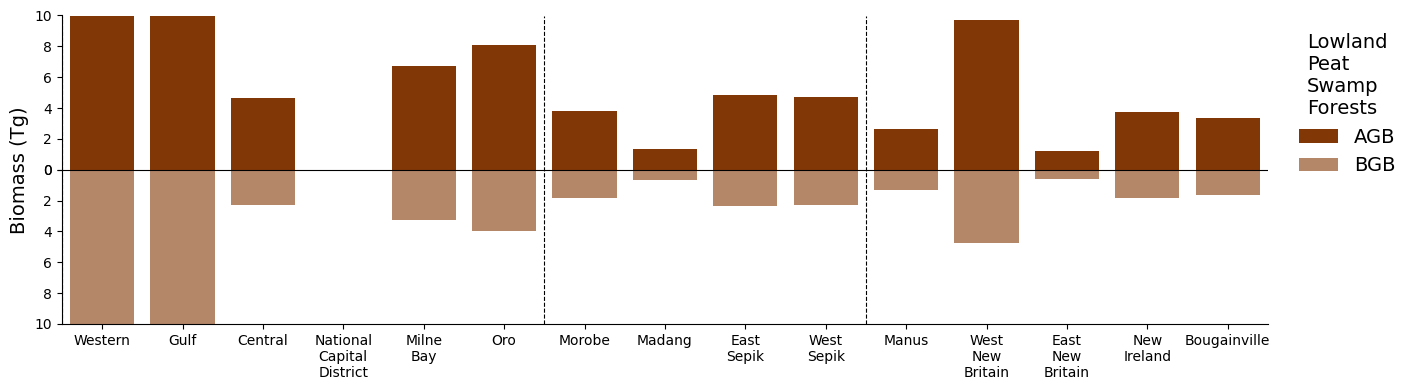

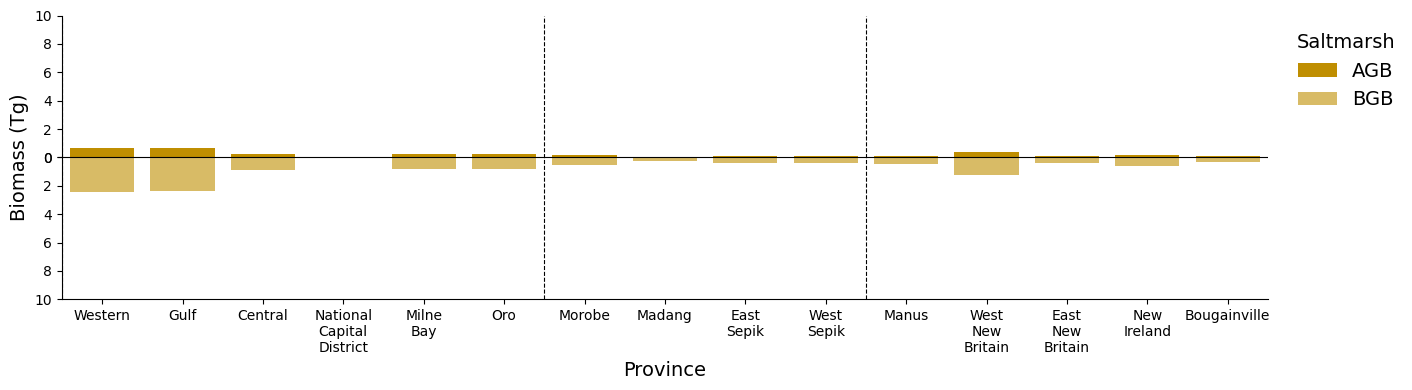

In [13]:
# Load data
data = pd.read_csv('./biomass_AGB_BGB_Tg.csv')
df = pd.DataFrame(data)

# Clean column names and string data
df.columns = df.columns.str.strip()
df['Region'] = df['Region'].str.strip()
df['Province'] = df['Province'].str.strip()
df['Biomass'] = df['Biomass'].str.strip()

# Set multi-index without sorting
df.set_index(['Region', 'Province', 'Biomass'], inplace=True)

# Unstack the 'Biomass' level into columns
df_unstacked = df.unstack(level='Biomass')

# Define correct province order per region
region_orders = {
    'Southern': ['Western', 'Gulf', 'Central', 'National Capital District', 'Milne Bay', 'Oro'],
    'Momase': ['Morobe', 'Madang', 'East Sepik', 'West Sepik'],
    'Islands': ['Manus', 'West New Britain', 'East New Britain', 'New Ireland', 'Bougainville']
}

# Habitat columns
habitats = ['Seagrass', 'Mangrove', 'Lowland Peat Swamp Forests', 'Saltmarsh']

# Build ordered MultiIndex
ordered_index = []
for region in region_orders:
    for province in region_orders[region]:
        ordered_index.append((region, province))
ordered_index = pd.MultiIndex.from_tuples(ordered_index, names=['Region', 'Province'])

# Reindex the unstacked data
df_unstacked.index = pd.MultiIndex.from_tuples(
    [(r.strip(), p.strip()) for r, p in df_unstacked.index],
    names=['Region', 'Province']
)
df_unstacked = df_unstacked.reindex(ordered_index)

# Wrap province labels if needed
def wrap_label(label):
    return '\n'.join(label.split()) if len(label.split()) >= 2 else label

# Color scheme
PNG_BCE_COLOUR_SCHEME = {
    'Mangrove': (168, 168, 0, 255),
    'Lowland Peat Swamp Forests': (130, 56, 6, 255),
    'Saltmarsh': (191, 142, 1, 255),
    'Seagrass': (96, 189, 150, 255),
}
color_map = {h: tuple(c / 255 for c in PNG_BCE_COLOUR_SCHEME[h][:3]) for h in habitats}

# # Mangrove and Lowland Peat Swamp Forest
# # MANUAL Y-AXIS CONTROL WITH DIFFERENT INTERVALS
# Y_MAX = 60    # Maximum y-value (40 Tg)
# Y_MIN = -30  # Minimum y-value (-200 Tg)
# POS_TICK_INTERVAL = 10  # Positive ticks every 20 Tg
# NEG_TICK_INTERVAL = 10 # Negative ticks every 100 Tg

# Saltmarsh
# MANUAL Y-AXIS CONTROL WITH DIFFERENT INTERVALS
Y_MAX = 10    # Maximum y-value (40 Tg)
Y_MIN = -10  # Minimum y-value (-200 Tg)
POS_TICK_INTERVAL = 2  # Positive ticks every 20 Tg
NEG_TICK_INTERVAL = 2 # Negative ticks every 100 Tg

# # Seagrass
# # MANUAL Y-AXIS CONTROL WITH DIFFERENT INTERVALS
# Y_MAX = 0.01    # Maximum y-value (40 Tg)
# Y_MIN = -0.01  # Minimum y-value (-200 Tg)
# POS_TICK_INTERVAL = 0.002  # Positive ticks every 20 Tg
# NEG_TICK_INTERVAL = 0.002 # Negative ticks every 100 Tg

# Generate tick positions - different intervals for positive/negative
positive_ticks = np.arange(0, Y_MAX + POS_TICK_INTERVAL, POS_TICK_INTERVAL)
negative_ticks = np.arange(0, Y_MIN - NEG_TICK_INTERVAL, -NEG_TICK_INTERVAL)
y_ticks = np.sort(np.concatenate([negative_ticks, positive_ticks]))

# Generate tick labels (absolute values)
y_tick_labels = [str(abs(int(y))) if y != 0 else '0' for y in y_ticks]

# # for seagrass to 3 decimal points
# y_tick_labels = [f"{abs(y):.3f}" if y != 0 else '0' for y in y_ticks]

# Plotting
for i, habitat in enumerate(habitats):
    fig, ax = plt.subplots(figsize=(14, 4))

    agb = df_unstacked[(habitat, 'AGB')]
    bgb = df_unstacked[(habitat, 'BGB')]
    
    provinces = [wrap_label(prov) for prov in agb.index.get_level_values('Province')]
    regions = agb.index.get_level_values('Region')

    x = range(len(provinces))
    ax.bar(x, agb.values, color=color_map[habitat], label='AGB')
    ax.bar(x, -bgb.values, color=color_map[habitat], alpha=0.6, label='BGB')

    # Region markers
    prev_region = None
    for j, (province, region) in enumerate(zip(provinces, regions)):
        if region != prev_region:
            ax.axvline(j - 0.5, color='black', linestyle='--', linewidth=0.8)
            if i == 0:  # Only add region label text on first figure
                ax.text(j, Y_MAX * 1.1, region, ha='left', va='top', fontsize=14)
            prev_region = region

    # Apply manual axis settings
    ax.set_ylim(Y_MIN, Y_MAX)
    ax.set_yticks(y_ticks)
    ax.set_yticklabels(y_tick_labels, fontsize=10)
    
    # X-axis formatting
    ax.set_xticks(x)
    ax.set_xticklabels(provinces, rotation=0, fontsize=10)
    ax.set_xlim(-0.5, len(provinces) - 0.5)
    ax.axhline(0, color='black', linewidth=0.8)
    
    # Labels
    ax.set_ylabel('Biomass (Tg)', fontsize=14)
    if i == len(habitats) - 1:  # Only label x-axis on last figure
        ax.set_xlabel('Province', fontsize=14)

    # Legend
    legend = ax.legend(loc='upper right', bbox_to_anchor=(1.12, 1), frameon=False, fontsize=14)
    legend.set_title(wrap_label(habitat), prop={'size': 14})

    # Final touches
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    plt.subplots_adjust(right=0.85)
    plt.tight_layout()

    # Save figures individually
    plt.savefig(f'./{habitat}_biomass_figure.png', bbox_inches='tight', dpi=300)
    
    plt.show()
    plt.close()
